# 01 — Moving Average Crossover

The simplest trend-following strategy. The idea: if the short-term average price is above the long-term average, the asset is in an uptrend — stay long.

**Signal rule:**
- short MA > long MA → long (1)
- short MA < long MA → out of market (0)

The classic version uses 50-day and 200-day windows. A cross upward is called a *Golden Cross*, a cross downward a *Death Cross*.

**Key limitation:** moving averages lag the price. By the time a signal fires, part of the move is already over. Works well in trending markets, badly in choppy ones.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_prices
from backtester import run
from metrics import summary
from strategies.ma_crossover import signals

In [2]:
ticker = 'NVDA'
start  = '2015-01-01'
end    = '2025-01-01'

prices = load_prices(ticker, start, end)
print(f"Loaded {len(prices)} trading days for {ticker}")

Loaded 2516 trading days for NVDA


## Generate signals and run backtest

In [3]:
short_window = 50
long_window  = 150

sig    = signals(prices, short_window, long_window)
result = run(prices, sig, initial_capital=10_000, transaction_cost=0.001)

print(f"\nPerformance ({ticker}, {start} — {end})")
print(f"  Windows: {short_window}/{long_window} MA")
print()
summary(result['equity'], result['strategy_ret'])


Performance (NVDA, 2015-01-01 — 2025-01-01)
  Windows: 50/150 MA

  Annualized return     : 82.45%
  Sharpe ratio          : 1.64
  Max drawdown          : -45.12%
  Calmar ratio          : 1.83
  Win rate              : 55.49%
  Total trades          : 1968


{'Annualized return': '82.45%',
 'Sharpe ratio': '1.64',
 'Max drawdown': '-45.12%',
 'Calmar ratio': '1.83',
 'Win rate': '55.49%',
 'Total trades': 1968}

## Strategy vs. buy-and-hold

The most important comparison: does timing the market beat just holding it?

C:\Users\ls200\AppData\Local\Temp\ipykernel_24928\2236865744.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  buys = result[result['trade'] == 1][result['position'] == 1]
C:\Users\ls200\AppData\Local\Temp\ipykernel_24928\2236865744.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sells = result[result['trade'] == 1][result['position'] == 0]


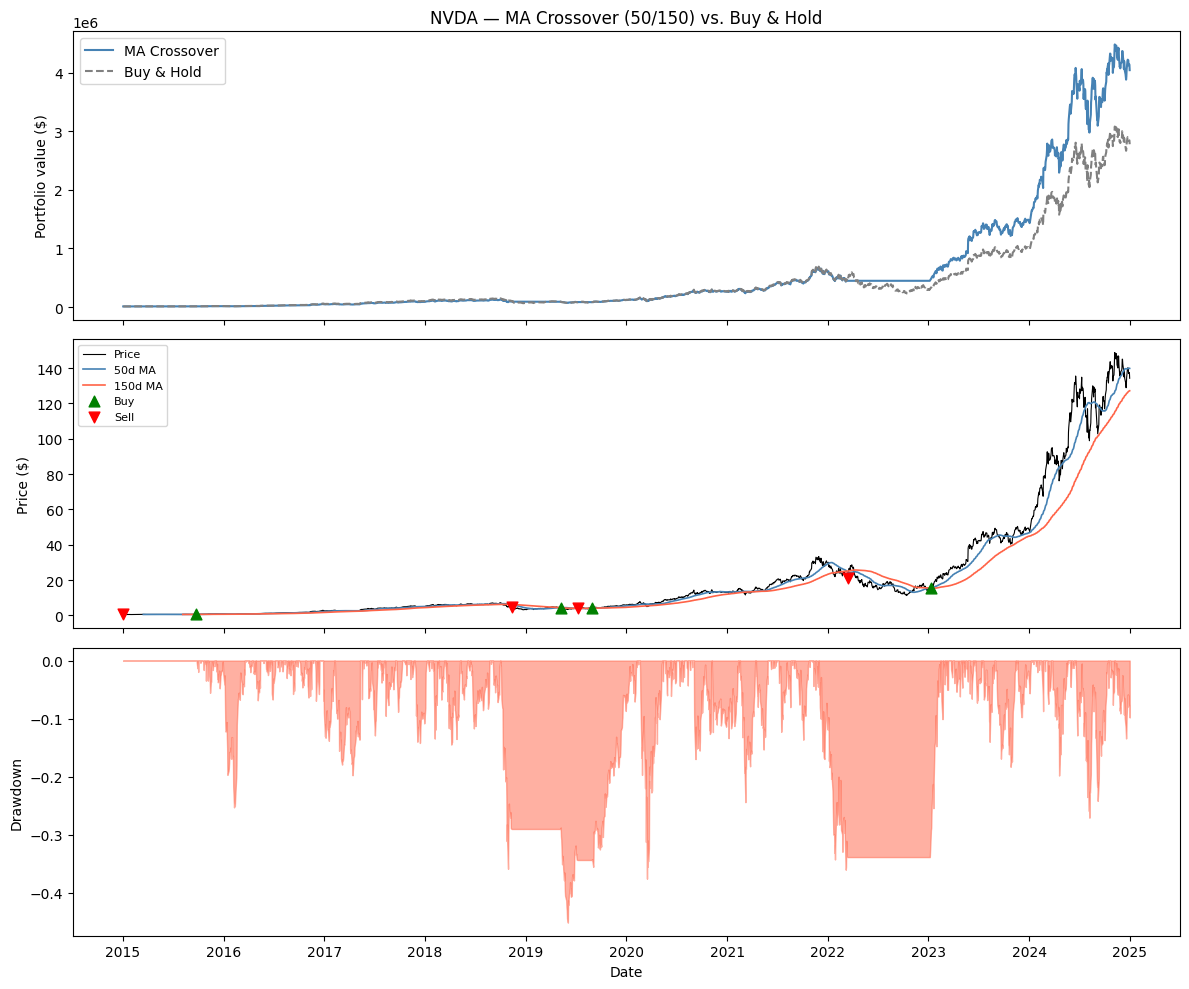

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# equity curves
axes[0].plot(result.index, result['equity'],    label='MA Crossover', color='steelblue')
axes[0].plot(result.index, result['bh_equity'], label='Buy & Hold',   color='gray', linestyle='--')
axes[0].set_ylabel('Portfolio value ($)')
axes[0].set_title(f'{ticker} — MA Crossover ({short_window}/{long_window}) vs. Buy & Hold')
axes[0].legend()

# price with moving averages and signals
short_ma = prices.rolling(short_window).mean()
long_ma  = prices.rolling(long_window).mean()

axes[1].plot(prices.index, prices,    color='black',     linewidth=0.8, label='Price')
axes[1].plot(prices.index, short_ma,  color='steelblue', linewidth=1.2, label=f'{short_window}d MA')
axes[1].plot(prices.index, long_ma,   color='tomato',    linewidth=1.2, label=f'{long_window}d MA')

# mark buy signals
buys = result[result['trade'] == 1][result['position'] == 1]
sells = result[result['trade'] == 1][result['position'] == 0]
axes[1].scatter(buys.index,  buys['price'],  marker='^', color='green', zorder=5, s=60, label='Buy')
axes[1].scatter(sells.index, sells['price'], marker='v', color='red',   zorder=5, s=60, label='Sell')
axes[1].set_ylabel('Price ($)')
axes[1].legend(fontsize=8)

# drawdown
rolling_max = result['equity'].cummax()
drawdown    = (result['equity'] - rolling_max) / rolling_max
axes[2].fill_between(result.index, drawdown, 0, color='tomato', alpha=0.5)
axes[2].set_ylabel('Drawdown')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Parameter sensitivity

How does the Sharpe ratio change across different window combinations? This is called a parameter sweep — useful to check whether the strategy is genuinely robust or just overfit to one lucky configuration.

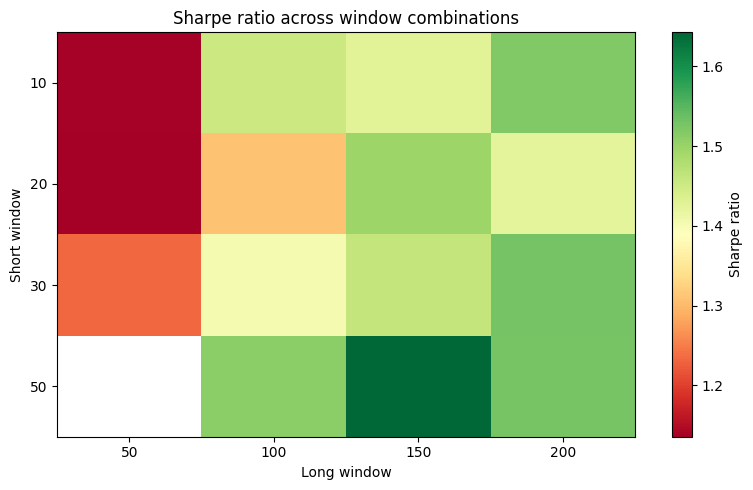

In [5]:
from metrics import sharpe_ratio

short_windows = [10, 20, 30, 50]
long_windows  = [50, 100, 150, 200]

sharpe_grid = pd.DataFrame(index=short_windows, columns=long_windows, dtype=float)

for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            sharpe_grid.loc[sw, lw] = np.nan
            continue
        sig = signals(prices, sw, lw)
        res = run(prices, sig)
        sharpe_grid.loc[sw, lw] = sharpe_ratio(res['strategy_ret'])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sharpe_grid.values.astype(float), cmap='RdYlGn', aspect='auto')
fig.colorbar(im, ax=ax, label='Sharpe ratio')
ax.set_xticks(range(len(long_windows)))
ax.set_yticks(range(len(short_windows)))
ax.set_xticklabels(long_windows)
ax.set_yticklabels(short_windows)
ax.set_xlabel('Long window')
ax.set_ylabel('Short window')
ax.set_title('Sharpe ratio across window combinations')
plt.tight_layout()
plt.show()